# Выполнил: Салабай Валерий; Группа:ФПэ-01-22

# Домашняя работа
Построить графики зависимостией $\varphi(\varepsilon)$, $\eta_i(\varepsilon)$, $H(\varepsilon)$, для $\eta_т$=0.88, $\eta_к$ = 0.85, при различных значениях температуры перед газовой турбиной $T_c$ и температурой воздуха перед компрессором $t_a=0$ C. m = 0.25, $\delta == \varepsilon$, $\eta_{кс}$ = 1. 

$t_c$ = 400, 500, 600, 700, 800, 900, 1200, 1400 C

Найти оптимум по мощности и по КПД для температуры $t_c$ = 1200 и построить на графиках в этих точках вертикальную линию (или поставить заметную точку на соответствующей кривой)

In [205]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

## Исходные данные 

In [208]:
effect_t = 0.88
effect_k = 0.85
effect_kc = 1
t_a = 0
m = 0.25
t_c = np.array([400,500,600,700,800,900,1200,1400])
Cp = 1200

### Промежуточные расчеты

In [211]:
tau = ((t_c) + 273.15)/((t_a) + 273.15)
E_max = (tau * effect_t * effect_k) ** (1/m)
shag_size = (E_max )/10000

### Построения графика зависимости КПД от степени повышения давления

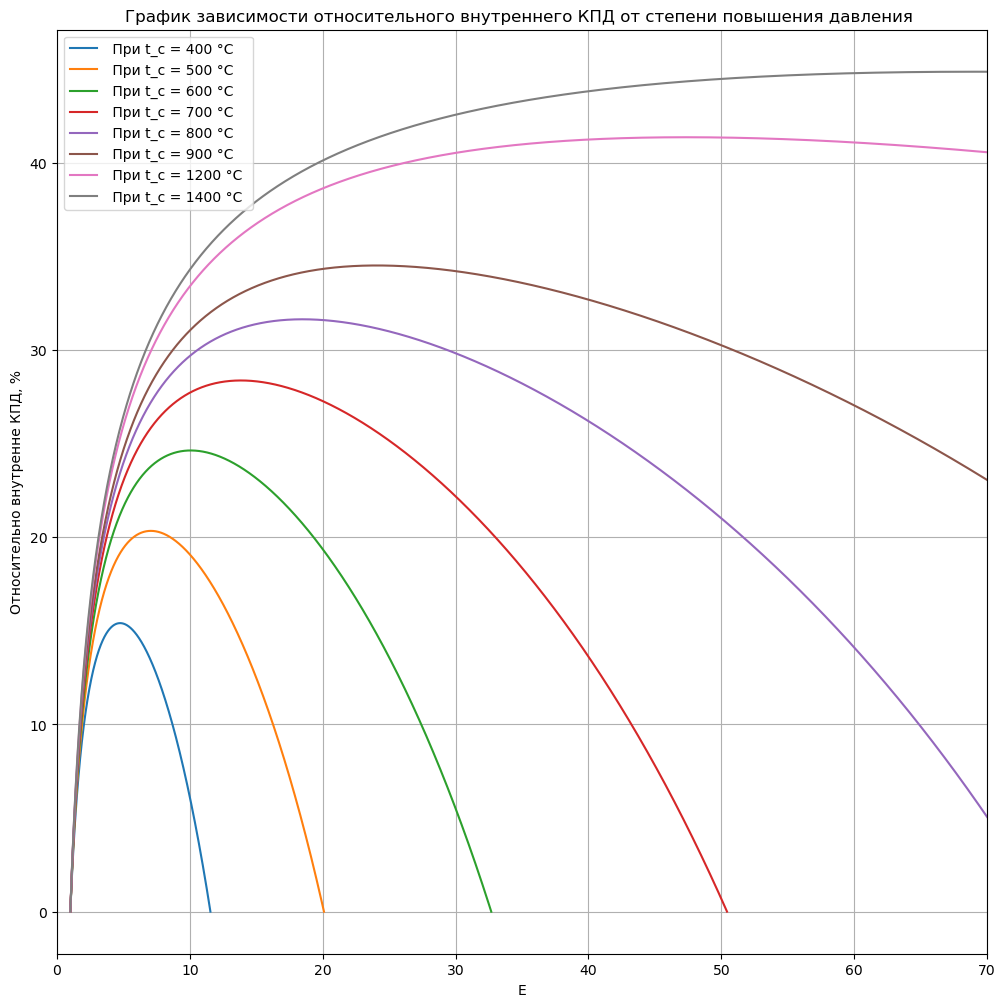

In [214]:
fig, graf = plt.subplots(1, 1, figsize=(12, 12))
for i in range(0,8,1):
 efficiency = []
 eps = []
 for E in np.arange(1,E_max[i],shag_size[i]):
  eps_value = E 
  num_1 = tau[i] * effect_t * (1 - E ** (-m)) 
  num_2 = (E ** m - 1) / effect_k
  denum = tau[i] - 1 - (E ** m - 1) / effect_k
  efficiency_value = (num_1 - num_2) / denum
  efficiency.append(efficiency_value*100)
  eps.append(eps_value)
 graf.set_title("График зависимости относительного внутреннего КПД от степени повышения давления ")
 graf.set_xlabel("E")
 graf.set_ylabel("Относительно внутренне КПД, %")
 graf.set_xlim(0, 70)
 graf.plot(eps,efficiency, label = f" При t_c = {t_c[i]} °C ")
graf.grid()
graf.legend();

----------------------------------------------------------------------------------------------------------------------------------

### Построение графика зависимости коэффициента полезной работы цикла от степени повышения давления

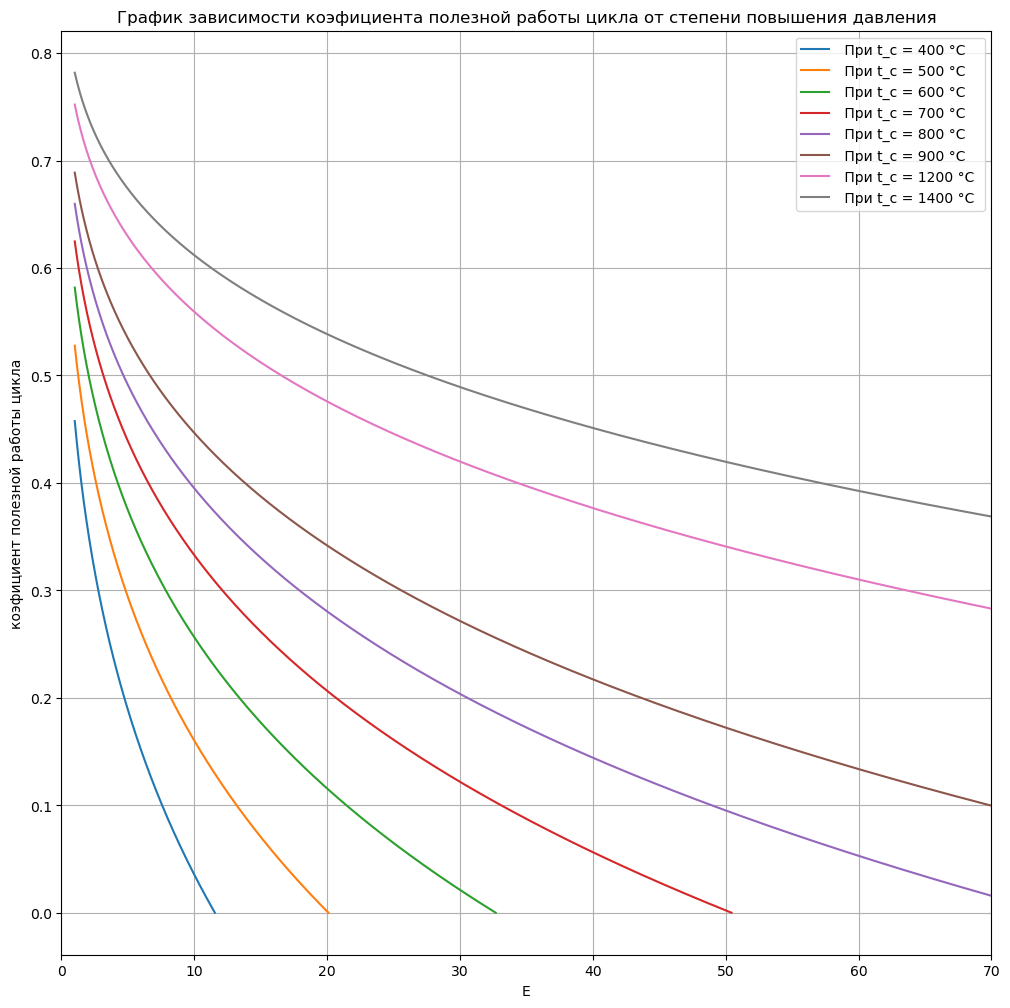

In [218]:
fig, graf = plt.subplots(1, 1, figsize=(12, 12))
for i in range(0,8,1):
 work_coefficient = []
 eps = []
 for E in np.arange(1,E_max[i],shag_size[i]):
  eps_value = (E) 
  num = eps_value ** m 
  denum = tau[i] * effect_t * effect_k
  work_coefficient_value = 1 - num/denum
  work_coefficient.append(work_coefficient_value)
  eps.append(eps_value)
 graf.set_title("График зависимости коэффициента полезной работы цикла от степени повышения давления")
 graf.set_xlabel("E")
 graf.set_ylabel("коэффициент полезной работы цикла")
 graf.set_xlim(0, 70)
 graf.plot(eps,work_coefficient, label = f" При t_c = {t_c[i]} °C ")
graf.grid()
graf.legend();
    

---------------------------------------------------------------------------------------------------------------

### Построение графика зависимости полезной работы цикла от степени повышения давления

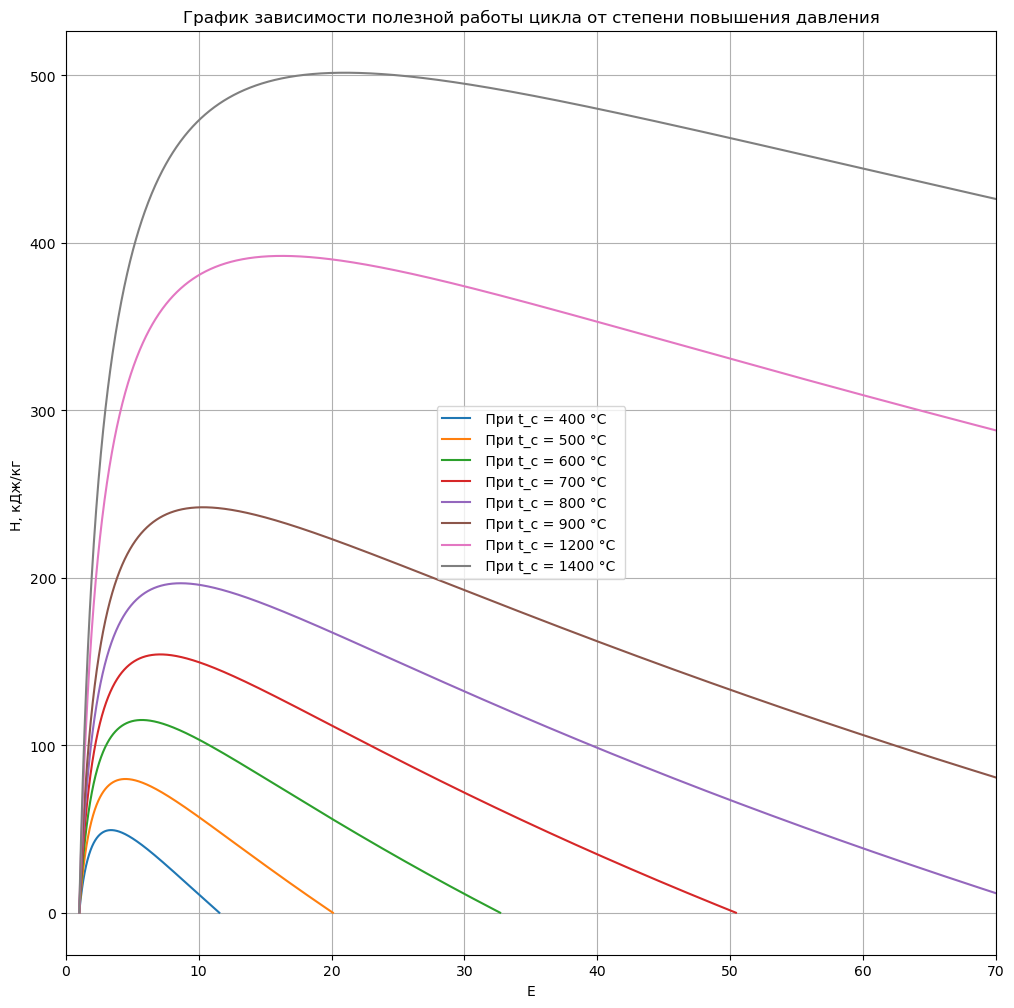

In [241]:
fig, graf = plt.subplots(1, 1, figsize=(12, 12))
for i in range(0,8,1):
 H = []
 eps = []
 for E in np.arange(1,E_max[i],shag_size[i]):
  eps_value = (E) 
  H_t = Cp * (t_c[i] +273.15) * (1 - E ** (-m)) * effect_t
  H_k = Cp * (t_a +273.15) * ((E ** m) - 1) / effect_k
  H_value = (H_t - H_k)/1000
  H.append(H_value)
  eps.append(eps_value)
 graf.set_title("График зависимости полезной работы цикла от степени повышения давления")
 graf.set_xlabel("E")
 graf.set_ylabel("H, кДж/кг ")
 graf.set_xlim(0, 70)
 graf.plot(eps,H, label = f" При t_c = {t_c[i]} °C ")
graf.grid()
graf.legend();

--------------------------------------------------------------------------------------------------------------

### Построение графика зависимости относительного внутреннего КПД от степени повышения давления

[47.32174728] [41.35692087]


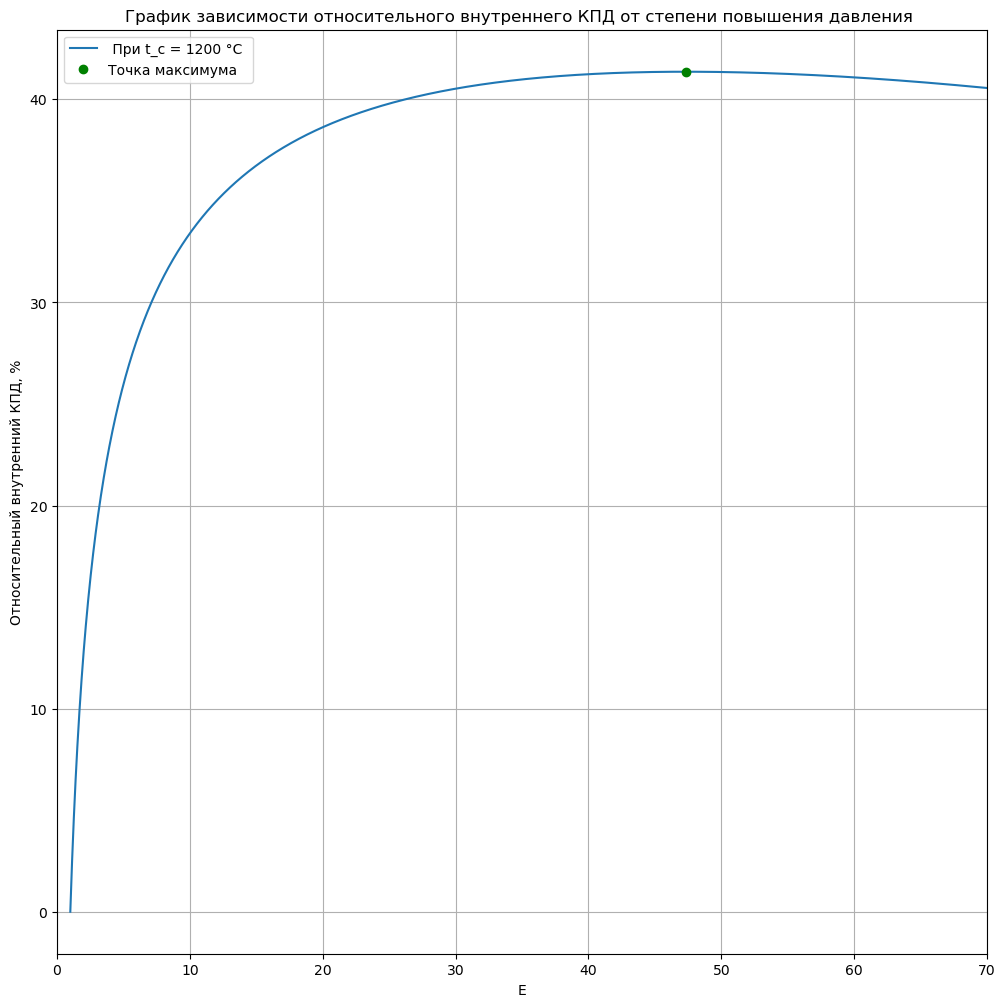

In [247]:
E_max_1200 = E_max[6]
shag_1200 = shag_size[6]
tau_1200 = tau[6]
fig, graf = plt.subplots(1, 1, figsize=(12, 12))
efficiency = []
eps = []
efficiency_opt = 0

def efficiency_for_opt(E):
    num_1 = tau_1200 * effect_t * (1 - E ** (-m)) 
    num_2 = (E ** m - 1) / effect_k
    denum = tau_1200 - 1 - (E ** m - 1) / effect_k
    efficiency_value = (num_1 - num_2) / denum
    return 1 - efficiency_value

for E in np.arange(1, E_max_1200, shag_1200):
    eps_value = E 
    num_1 = tau_1200 * effect_t * (1 - E ** (-m)) 
    num_2 = (E ** m - 1) / effect_k
    denum = tau_1200 - 1 - (E ** m - 1) / effect_k
    efficiency_value = (num_1 - num_2) / denum
    efficiency.append(efficiency_value * 100)
    eps.append(eps_value)

bounds = ([0.1, 1])
opt = minimize(efficiency_for_opt, x0=0.1, tol=1e-8)
eps_opt = opt.x
efficiency_opt = (1 - efficiency_for_opt(eps_opt)) * 100  # Исправлено здесь
print(eps_opt, efficiency_opt)

graf.set_title("График зависимости относительного внутреннего КПД от степени повышения давления ")
graf.set_xlabel("E")
graf.set_ylabel("Относительный внутренний КПД, %")
graf.set_xlim(0, 70)
graf.plot(eps, efficiency, label=f" При t_c = {t_c[6]} °C ")
graf.plot(eps_opt, efficiency_opt, 'go', label="Точка максимума") 
graf.grid()
graf.legend()

--------------------------------------------------------------------------------------------------------------

### Поиск точки максимума и построение графика зависимости полезной работы цикла от степени повышения давления

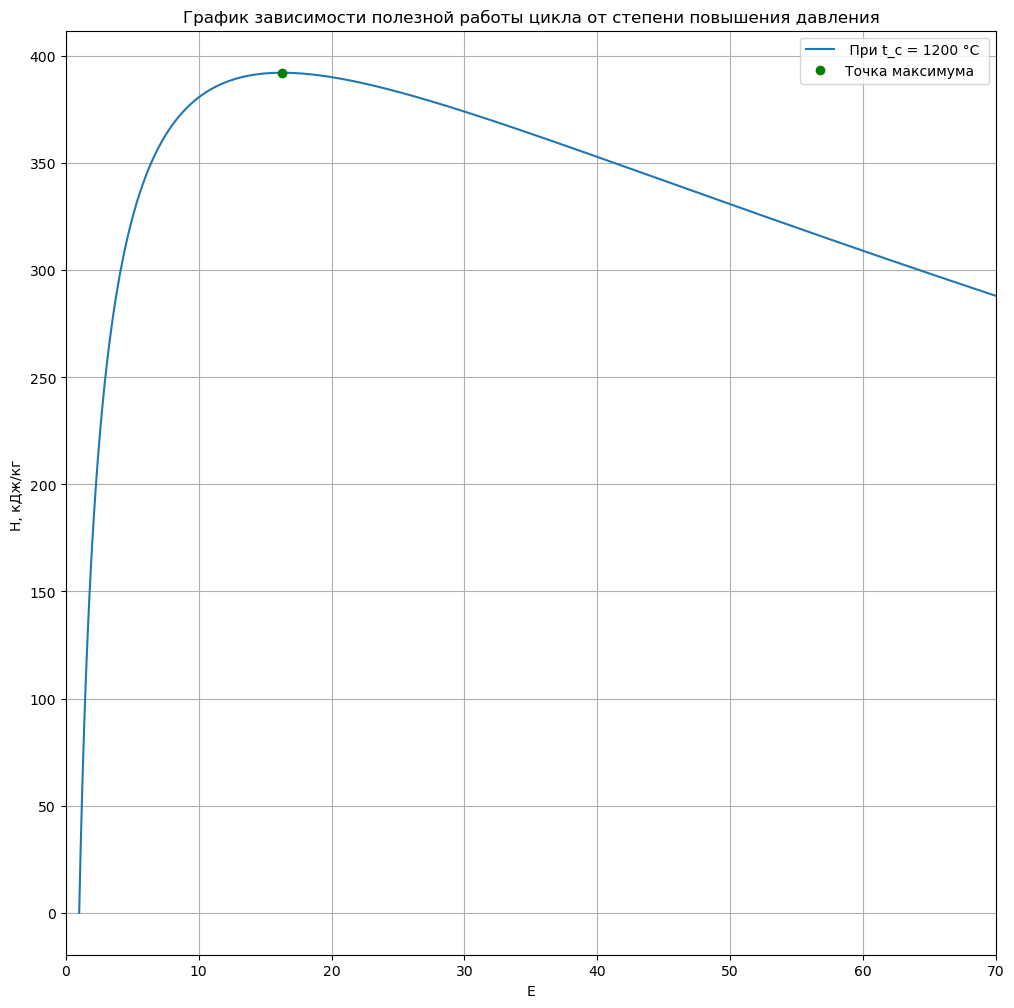

In [253]:
'''Определения точки максимума на графике 
зависимости полезной работы цикла от степени повышения давления'''
E_max_1200 = E_max[6]
shag_1200 = shag_size[6]
tau_1200 = tau[6]
fig, graf = plt.subplots(1, 1, figsize=(12, 12))
H = []
eps = []
for E in np.arange(1,E_max_1200,shag_1200):
  eps_value = (E) 
  H_t = Cp * (t_c[6] +273.15) * (1 - E ** (-m)) * effect_t
  H_k = Cp * (t_a +273.15) * ((E ** m) - 1) / effect_k
  H_value = (H_t - H_k)/1000
  H.append(H_value)
  eps.append(eps_value)
eps_opt = (tau_1200 * effect_k * effect_t) ** (1/(2 * m))
# Поиск максимума 
H_t = Cp * (t_c[6] +273.15) * (1 - eps_opt ** (-m)) * effect_t
H_k = Cp * (t_a +273.15) * ((eps_opt ** m) - 1) / effect_k
H_max = (H_t - H_k)/1000
graf.set_title("График зависимости полезной работы цикла от степени повышения давления")
graf.set_xlabel("E")
graf.set_ylabel("H, кДж/кг ")
graf.set_xlim(0, 70)
graf.plot(eps,H, label = f" При t_c = {t_c[6]} °C ")
graf.plot(eps_opt,H_max , 'go' ,label = f"Точка максимума")
graf.grid()
graf.legend();